In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

## Load Data

In [2]:
try:
    base_dir = os.path.join(os.path.dirname(os.path.abspath(__file__)), "initial_data")
except NameError:
    base_dir = os.path.join(os.getcwd(), "..", "initial_data")
    base_dir = os.path.abspath(base_dir)

print("Looking for data in:", base_dir)
print("Path exists:", os.path.exists(base_dir))

# load f5
function_folder = os.path.join(base_dir, "function_5")
inputs = np.load(os.path.join(function_folder, "initial_inputs.npy"))
outputs = np.load(os.path.join(function_folder, "initial_outputs.npy"))

# reshape if needed
if inputs.ndim == 1:
    inputs = inputs.reshape(-1, 1)
if outputs.ndim == 1:
    outputs = outputs.reshape(-1, 1)

# create dataframe
input_cols = [f"X{j+1}" for j in range(inputs.shape[1])]
output_cols = [f"y{j+1}" for j in range(outputs.shape[1])]

df_f5 = pd.DataFrame(
    np.concatenate([inputs, outputs], axis=1),
    columns=input_cols + output_cols
)

print(f"Loaded function 5: shape = {df_f5.shape}, columns = {df_f5.columns.tolist()}")



Looking for data in: C:\Users\Hassa\OneDrive - Loughborough University\current\ML & AI\Capstone Project\initial_data
Path exists: True
Loaded function 5: shape = (20, 5), columns = ['X1', 'X2', 'X3', 'X4', 'y1']


In [3]:
week1_results = {"f5": ([0.037069, 0.974641, 0.864911, 0.019169], 684.5607486761136)}

In [4]:
week2_results = {"f5": ([0.624000, 0.735500, 0.976700, 0.994100], 2434.328593289806)}

In [5]:
week3_results = {"f5": ([0.898795, 0.963833, 1.000000, 0.791851], 4171.124196806389)}

In [6]:
week4_results = {"f5": ([0.072013, 0.315203, 0.125702, 0.883341], 15.250051561683966)}

In [7]:
week5_results = {"f5": ([0.260034, 0.558879, 0.984293, 0.063132], 225.88673947929044)}

In [8]:
week6_results = {"f5": ([0.000000, 0.856410, 1.000000, 0.433460], 849.8436606636637)}

In [9]:
week7_results = {"f5": ([0.998891, 0.926298, 0.985415, 0.964459], 6575.295982756673)}

In [10]:
week8_results = {"f5": ([0.714539, 0.952855, 0.995586, 0.996033], 4660.244115920329)}

In [11]:
week9_results = {"f5": ([0.989950, 0.998195, 0.862178, 0.991837], 6294.324532147924)}

In [12]:
week10_results = {"f5": ([0.999929, 0.967465, 0.953159, 0.982308], 6971.761526528202)}

In [13]:
week11_results = {"f5": ([0.999762, 0.987560, 0.981113, 0.981076], 7735.182974570735)}

In [14]:
week12_results = {"f5": ([0.999700, 0.999800, 0.998700, 0.977900], 8219.09203524906)}

In [15]:
weekly_results = {
    "week1": week1_results,
    "week2": week2_results,
    "week3": week3_results,
    "week4": week4_results,
    "week5": week5_results,
    "week6": week6_results,
    "week7": week7_results,
    "week8": week8_results,
    "week9": week9_results,
    "week10": week10_results,
    "week11": week11_results,
    "week12": week12_results,
}

output_col = output_cols[0]   # this gives "y1"

# add weekly results to df_f5

for week, results in weekly_results.items():
    
    if "f5" not in results:
        continue
    
    inputs, output = results["f5"]
    
    # convert to numpy arrays
    inputs = np.array(inputs).reshape(1, -1)
    output = np.array([output]).reshape(1, -1)
    
    # build dataframe row with the same columns as df_f5
    df_new_row = pd.DataFrame(
        np.concatenate([inputs, output], axis=1),
        columns=["X1", "X2", "X3", "X4", "y1"]
    )
    
    # append to df_f5
    df_f5 = pd.concat([df_f5, df_new_row], ignore_index=True)
    
    # remove duplicates
    df_f5 = df_f5.drop_duplicates(ignore_index=True)

print("updated f5 shape:", df_f5.shape)


updated f5 shape: (32, 5)


In [16]:
print(df_f5)

          X1        X2        X3        X4           y1
0   0.191447  0.038193  0.607418  0.414584    64.443440
1   0.758653  0.536518  0.656000  0.360342    18.301380
2   0.438350  0.804340  0.210245  0.151295     0.112940
3   0.706051  0.534192  0.264243  0.482088     4.210898
4   0.836478  0.193610  0.663893  0.785649   258.370525
5   0.683432  0.118663  0.829046  0.567577    78.434389
6   0.553621  0.667350  0.323806  0.814870    57.571537
7   0.352356  0.322242  0.116979  0.473113   109.571876
8   0.153786  0.729382  0.422598  0.443074     8.847992
9   0.463442  0.630025  0.107906  0.957644   233.223610
10  0.677491  0.358510  0.479592  0.072880    24.423088
11  0.583973  0.147243  0.348097  0.428615    64.420147
12  0.306889  0.316878  0.622634  0.095399    63.476716
13  0.511142  0.817957  0.728710  0.112354    79.729130
14  0.438933  0.774092  0.378167  0.933696   355.806818
15  0.224189  0.846480  0.879484  0.878516  1088.859618
16  0.725262  0.479870  0.088947  0.759760    28

In [17]:
display(df_f5.describe().T)  

,count,mean,std,min,25%,50%,75%,max
X1,32.0,0.525076,0.319067,0.000000,0.251073,0.532382,0.733610,0.999929
X2,32.0,0.631493,0.304313,0.038193,0.349443,0.698366,0.878480,0.999800
X3,32.0,0.633957,0.317538,0.088947,0.370650,0.659947,0.959044,1.000000
X4,32.0,0.592908,0.351539,0.019169,0.317886,0.663668,0.939683,0.996033
y1,32.0,1620.697896,2680.514463,0.112940,41.102866,167.729308,1425.226862,8219.092035


## Feature vs y scatter plots with muted background

Feature vs y1 for f5 (highlighting top 8 points)


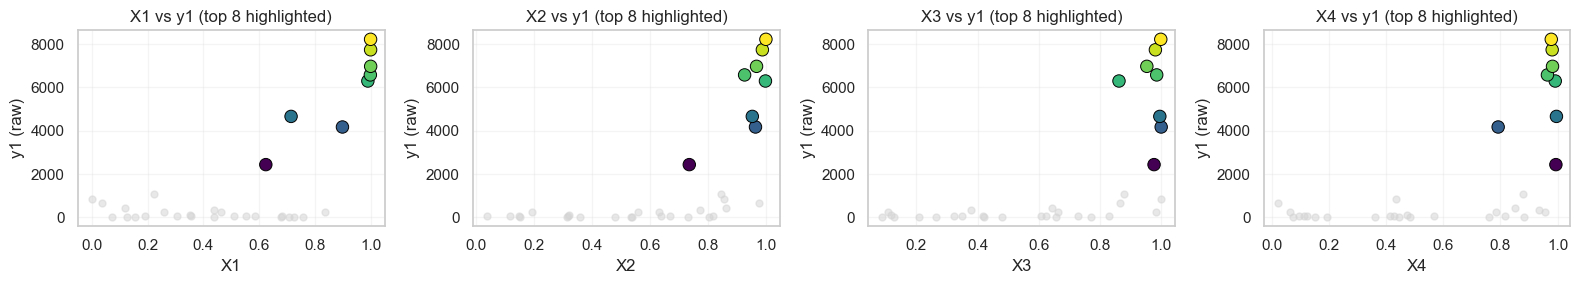

In [18]:
print("Feature vs y1 for f5 (highlighting top 8 points)")

# extract inputs and output for f5
input_cols_f5 = [c for c in df_f5.columns if c.startswith("X")]
X_f5 = df_f5[input_cols_f5].values
y_f5 = df_f5["y1"].values

# identify top 8 points by y
top_k = 8
top_idx = np.argsort(y_f5)[-top_k:]
y_top = y_f5[top_idx]
X_top = X_f5[top_idx]

# number of input features
n_features = X_f5.shape[1]
ncols = 4
nrows = int(np.ceil(n_features / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))

# flatten axes
if nrows * ncols == 1:
    axes = [axes]
else:
    axes = axes.ravel().tolist()

# plot each feature
for j, col in enumerate(input_cols_f5):
    ax = axes[j]

    # background scatter (all points, muted)
    ax.scatter(
        X_f5[:, j],
        y_f5,
        c="lightgray",
        s=25,
        alpha=0.5,
        label="all points"
    )

    # overlay top 8 points (coloured by rank)
    sc = ax.scatter(
        X_top[:, j],
        y_top,
        c=y_top,
        cmap="viridis",
        s=80,
        edgecolor="black",
        linewidth=0.7,
        label="top 8"
    )

    ax.set_xlabel(col)
    ax.set_ylabel("y1 (raw)")
    ax.set_title(f"{col} vs y1 (top 8 highlighted)")
    ax.grid(alpha=0.2)

# hide unused axes
for k in range(n_features, len(axes)):
    axes[k].axis("off")

plt.tight_layout()
plt.show()



## Distribution Analysis

f5 – feature and output distributions


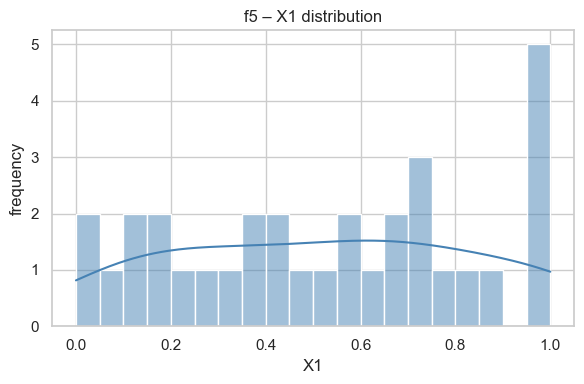

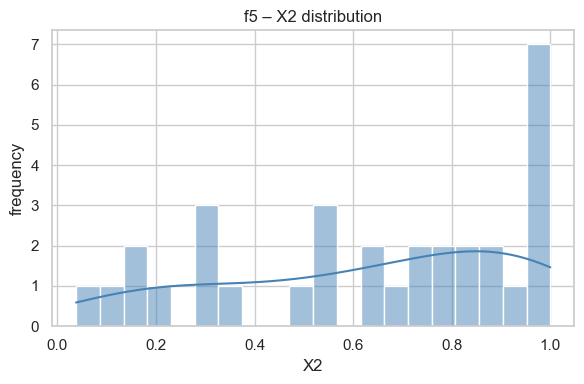

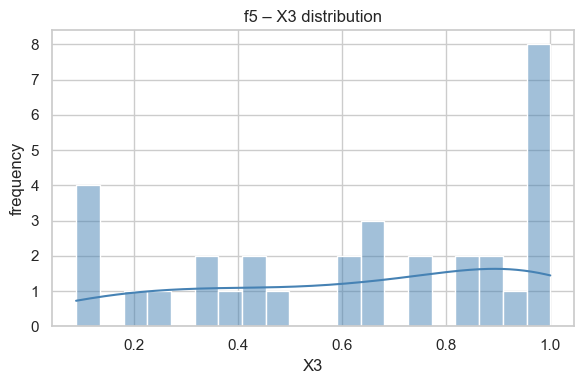

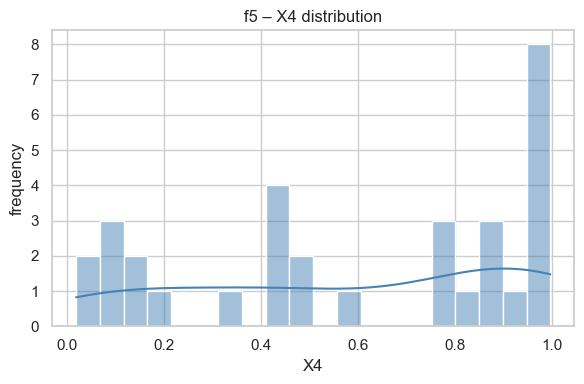

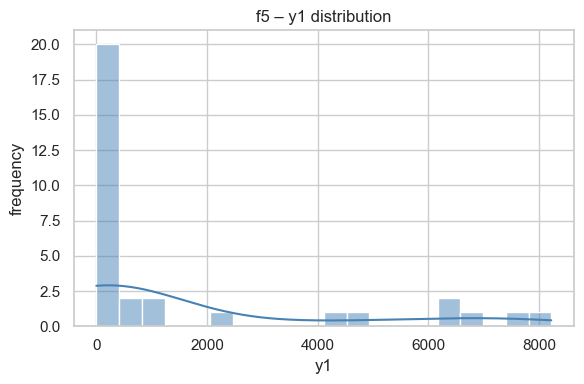

In [19]:
input_cols_f5 = [c for c in df_f5.columns if c.startswith("X")]
output_col_f5 = [c for c in df_f5.columns if c.startswith("y")][0]

print("f5 – feature and output distributions")

all_cols_raw_f5 = input_cols_f5 + [output_col_f5]

for col in all_cols_raw_f5:
    plt.figure(figsize=(6, 4))

    sns.histplot(
        df_f5[col],
        kde=True,
        bins=20,
        color="steelblue"
    )

    plt.title(f"f5 – {col} distribution")
    plt.xlabel(col)
    plt.ylabel("frequency")

    plt.tight_layout()
    plt.show()



## Y vs Instance Index

f5 – y vs instance index


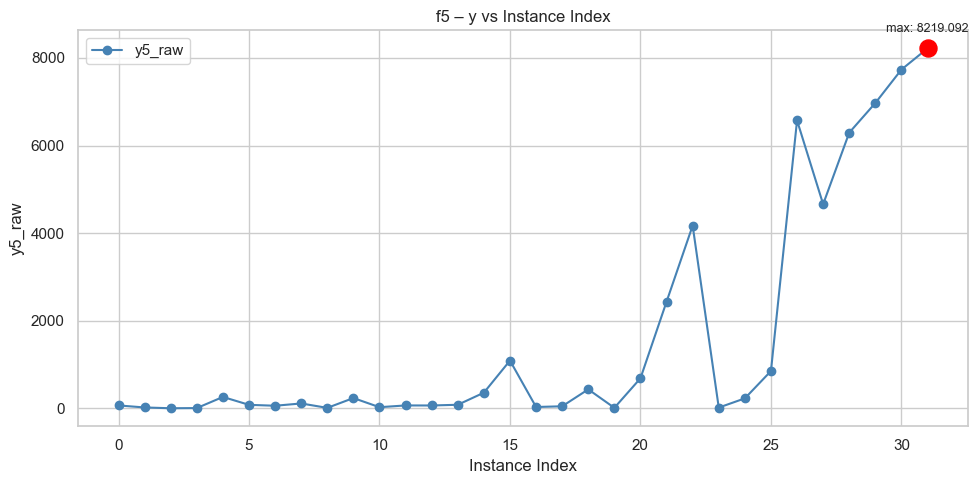

In [20]:
print("f5 – y vs instance index")

# clean copy of raw data
df_f5_plot = df_f5.copy()

# extract raw y
y_raw = df_f5_plot[output_col_f5].values
x = np.arange(len(y_raw))

plt.figure(figsize=(10, 5))

plt.plot(x, y_raw, marker="o", linestyle="-", color="steelblue", label="y5_raw")

# highlight maximum
max_idx = np.argmax(y_raw)
max_val = y_raw[max_idx]

plt.scatter(max_idx, max_val, s=150, color="red", zorder=5)
plt.annotate(
    f"max: {max_val:.3f}",
    (max_idx, max_val),
    textcoords="offset points",
    xytext=(0, 12),
    ha="center",
    fontsize=9
)

plt.title("f5 – y vs Instance Index")
plt.xlabel("Instance Index")
plt.ylabel("y5_raw")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



## Pearson Correlation

f5 Pearson Correlation Matrix (raw y1)


,X1,X2,X3,X4,y1
X1,1.000000,0.270305,0.263538,0.487837,0.688539
X2,0.270305,1.000000,0.451003,0.379846,0.633520
X3,0.263538,0.451003,1.000000,0.156986,0.614146
X4,0.487837,0.379846,0.156986,1.000000,0.596400
y1,0.688539,0.633520,0.614146,0.596400,1.000000


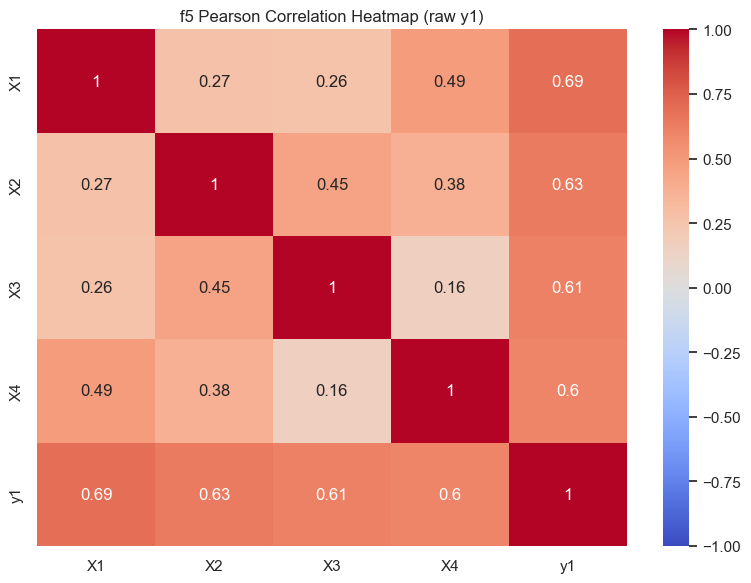

In [21]:
df_raw = df_f5.copy()

print("f5 Pearson Correlation Matrix (raw y1)")

corr_raw = df_raw.corr()
display(corr_raw)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_raw,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("f5 Pearson Correlation Heatmap (raw y1)")
plt.tight_layout()
plt.show()

## Spearman Correlation

f5 Spearman Correlation Matrix (raw y1)


,X1,X2,X3,X4,y1
X1,1.000000,0.301686,0.258088,0.508798,0.413856
X2,0.301686,1.000000,0.575933,0.451979,0.704545
X3,0.258088,0.575933,1.000000,0.243241,0.727889
X4,0.508798,0.451979,0.243241,1.000000,0.625733
y1,0.413856,0.704545,0.727889,0.625733,1.000000


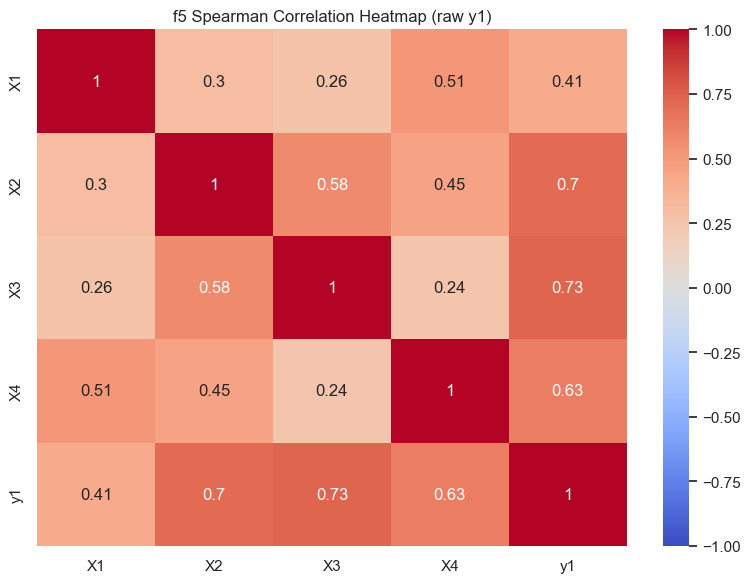

In [22]:
# spearman correlation with raw y1
df_raw = df_f5.copy()

print("f5 Spearman Correlation Matrix (raw y1)")

corr_raw_spearman = df_raw.corr(method="spearman")
display(corr_raw_spearman)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_raw_spearman,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("f5 Spearman Correlation Heatmap (raw y1)")
plt.tight_layout()
plt.show()


## Kendall Correlation

f5 Kendall Correlation Matrix (raw y1)


,X1,X2,X3,X4,y1
X1,1.000000,0.193548,0.163471,0.366935,0.266129
X2,0.193548,1.000000,0.365288,0.302419,0.508065
X3,0.163471,0.365288,1.000000,0.127144,0.526741
X4,0.366935,0.302419,0.127144,1.000000,0.423387
y1,0.266129,0.508065,0.526741,0.423387,1.000000


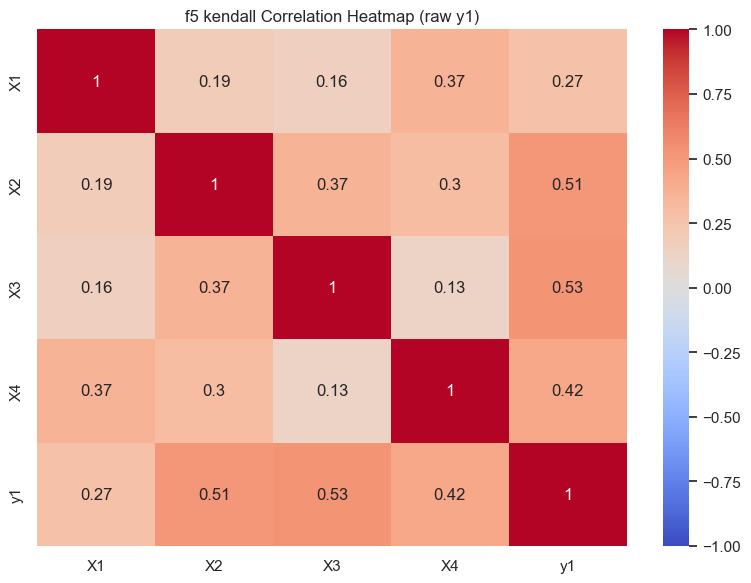

In [23]:
# Kendall correlation with raw y1
df_raw = df_f5.copy()

print("f5 Kendall Correlation Matrix (raw y1)")

corr_raw_kendall = df_raw.corr(method="kendall")
display(corr_raw_kendall)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_raw_kendall,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("f5 kendall Correlation Heatmap (raw y1)")
plt.tight_layout()
plt.show()


## Mutual Information

In [24]:
from sklearn.feature_selection import mutual_info_regression

print("f5 — Mutual Information with Output")

df_f5_raw = df_f5.copy()

# define inputs and output
input_cols_f5 = [c for c in df_f5_raw.columns if c.startswith("X")]
output_col_f5 = "y1"

X_f5 = df_f5_raw[input_cols_f5].values
y_f5 = df_f5_raw[output_col_f5].values

# compute mutual information
mi_f5 = mutual_info_regression(X_f5, y_f5, random_state=42)

# build dataframe
mi_f5_df = pd.DataFrame({
    "Feature": input_cols_f5,
    "Mutual_Info": mi_f5
}).sort_values(by="Mutual_Info", ascending=False)

display(mi_f5_df)


f5 — Mutual Information with Output


,Feature,Mutual_Info
1,X2,0.455587
0,X1,0.431072
2,X3,0.357365
3,X4,0.289627


## Partial Correlation

In [25]:
!pip install pingouin
import pingouin as pg

print("f5 (Raw y1) — Partial Correlation")

df_f5_raw = df_f5.copy()

# define inputs and output
input_cols_f5 = [c for c in df_f5_raw.columns if c.startswith("X")]
output_col_f5 = "y1"

# compute partial correlations for each X feature
for x in input_cols_f5:
    covars = [c for c in input_cols_f5 if c != x]  # all other X's as covariates
    
    pcorr_raw_f5 = pg.partial_corr(
        data=df_f5_raw,
        x=x,
        y=output_col_f5,
        covar=covars
    )
    
    print(f"\nPartial correlation for {x}:")
    display(pcorr_raw_f5)


f5 (Raw y1) — Partial Correlation

Partial correlation for X1:


,n,r,CI95%,p-val
pearson,32,0.621451,"[0.33, 0.8]",0.000321



Partial correlation for X2:


,n,r,CI95%,p-val
pearson,32,0.469593,"[0.12, 0.71]",0.010166



Partial correlation for X3:


,n,r,CI95%,p-val
pearson,32,0.568526,"[0.26, 0.77]",0.001292



Partial correlation for X4:


,n,r,CI95%,p-val
pearson,32,0.413213,"[0.06, 0.68]",0.025882


## Sliced Inverse Regression

SIR Analysis for f5
Leading SIR direction computed.
Bootstrap stability angle (deg): 15.85
Bootstrap samples used: 100
Eigenvalue ratio (λ1 / λ2): 3.563


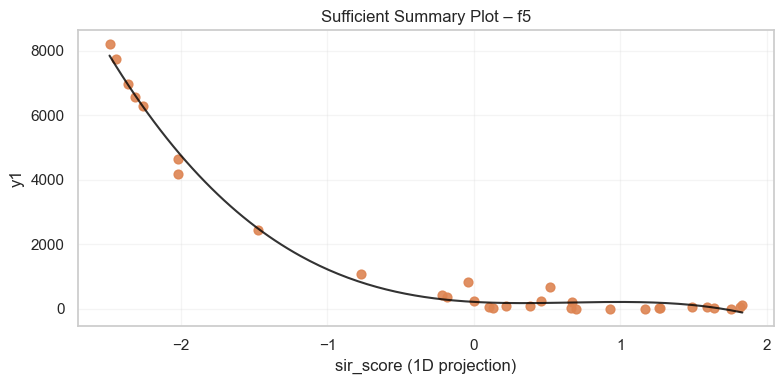


Leading SIR direction (first 8 components):
  X1: -0.4459
  X2: -0.5269
  X3: -0.5273
  X4: -0.4955

Top eigenvalues: [1.76709972 0.49601398 0.05909613]
Eigenvalue ratio: 3.563
Bootstrap stability angle: 15.85°


In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample


# SIR core implementation
def sliced_inverse_regression(X, y, n_slices=8):
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)

    n, p = Xs.shape
    n_slices = min(max(2, int(n_slices)), max(2, n))

    quantiles = np.linspace(0.0, 1.0, n_slices + 1)
    bins = np.quantile(y, quantiles)
    bins[0] -= 1e-12
    bins[-1] += 1e-12
    slice_idx = np.digitize(y, bins) - 1

    slice_means = np.zeros((n_slices, p))
    slice_probs = np.zeros(n_slices)

    for s in range(n_slices):
        mask = slice_idx == s
        if mask.sum() > 0:
            slice_means[s] = Xs[mask].mean(axis=0)
            slice_probs[s] = mask.sum() / n

    cov = np.zeros((p, p))
    for s in range(n_slices):
        m = slice_means[s].reshape(-1, 1)
        cov += slice_probs[s] * (m @ m.T)

    eigvals, eigvecs = np.linalg.eigh(cov)
    idx = np.argsort(eigvals)[::-1]

    leading = eigvecs[:, idx[0]]
    sir_dir = leading / (np.linalg.norm(leading) + 1e-12)

    sir_scores = Xs @ sir_dir
    return sir_dir, sir_scores, scaler, eigvals[idx]



# Bootstrap stability
def sir_bootstrap_stability(X, y, n_slices=8, n_boot=100, random_state=0):
    rng = np.random.RandomState(random_state)
    angles = []

    base_dir, _, _, _ = sliced_inverse_regression(X, y, n_slices=n_slices)

    for _ in range(n_boot):
        Xb, yb = resample(X, y, replace=True, random_state=rng)
        try:
            db, _, _, _ = sliced_inverse_regression(Xb, yb, n_slices=n_slices)
            cosang = np.clip(
                np.dot(base_dir, db) /
                (np.linalg.norm(base_dir) * np.linalg.norm(db) + 1e-12),
                -1.0, 1.0
            )
            ang = np.arccos(cosang)
            angles.append(ang)
        except Exception:
            continue

    angles = np.array(angles)
    return {
        "mean_angle_deg": np.degrees(np.nanmean(angles)),
        "std_angle_deg": np.degrees(np.nanstd(angles)),
        "n_boot": len(angles)
    }



# Run SIR on df_f5
print("SIR Analysis for f5")

df = df_f5.copy()
input_cols = [c for c in df.columns if c.startswith("X")]
output_col = [c for c in df.columns if c.startswith("y")][0]

X = df[input_cols].values.astype(float)
y = df[output_col].values.astype(float)

sir_dir, sir_scores, scaler, eigvals = sliced_inverse_regression(X, y, n_slices=8)
print("Leading SIR direction computed.")

stability = sir_bootstrap_stability(X, y, n_slices=8, n_boot=100)
print(f"Bootstrap stability angle (deg): {stability['mean_angle_deg']:.2f}")
print(f"Bootstrap samples used: {stability['n_boot']}")

eig_ratio = eigvals[0] / (eigvals[1] + 1e-12)
print(f"Eigenvalue ratio (λ1 / λ2): {eig_ratio:.3f}")

df_summary = df.copy()
df_summary["sir_score"] = sir_scores


# Summary plot
plt.figure(figsize=(8, 4))
plt.scatter(sir_scores, y, c="C1", s=40, alpha=0.9)
plt.xlabel("sir_score (1D projection)")
plt.ylabel(output_col)
plt.title("Sufficient Summary Plot – f5")
plt.grid(alpha=0.2)

try:
    coeffs = np.polyfit(sir_scores, y, 3)
    xs = np.linspace(sir_scores.min(), sir_scores.max(), 200)
    ys = np.polyval(coeffs, xs)
    plt.plot(xs, ys, color="black", linewidth=1.5, alpha=0.8)
except Exception:
    pass

plt.tight_layout()
plt.show()

print("\nLeading SIR direction (first 8 components):")
for j, comp in enumerate(sir_dir[:8]):
    print(f"  {input_cols[j]}: {comp:.4f}")

print(f"\nTop eigenvalues: {eigvals[:3]}")
print(f"Eigenvalue ratio: {eig_ratio:.3f}")
print(f"Bootstrap stability angle: {stability['mean_angle_deg']:.2f}°")


## Isomap

Isomap 1D Embedding for f5
Isomap: computed 1D embedding with n_neighbors=8


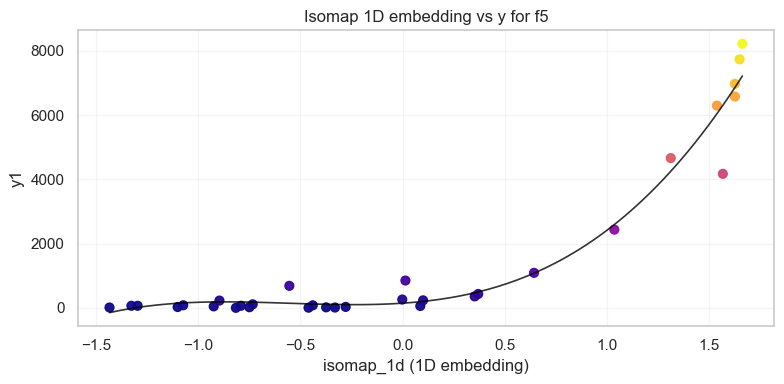

Isomap 1D: mean=0.0000, std=1.0000

Lowest isomap points (index, isomap, y):
  19: -1.4334, y=9.9723
  0: -1.3264, y=64.4434
  12: -1.2960, y=63.4767

Highest isomap points (index, isomap, y):
  26: 1.6253, y=6575.2960
  30: 1.6483, y=7735.1830
  31: 1.6616, y=8219.0920


In [27]:
from sklearn.manifold import Isomap

def compute_isomap_1d(X, n_neighbors=8):
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)

    iso = Isomap(n_components=1, n_neighbors=n_neighbors)
    emb = iso.fit_transform(Xs).ravel()

    emb = (emb - emb.mean()) / (emb.std() + 1e-12)
    return emb, iso, scaler


print("Isomap 1D Embedding for f5")

df = df_f5.copy()
input_cols = [c for c in df.columns if c.startswith("X")]
output_col = [c for c in df.columns if c.startswith("y")][0]

X = df[input_cols].values.astype(float)
y = df[output_col].values.astype(float)

# compute 1d isomap embedding
isomap_1d, iso_model, scaler = compute_isomap_1d(X, n_neighbors=8)
print("Isomap: computed 1D embedding with n_neighbors=8")


# isomap coordinate vs y plot
plt.figure(figsize=(8, 4))
plt.scatter(isomap_1d, y, c=y, cmap="plasma", s=40, alpha=0.95)
plt.xlabel("isomap_1d (1D embedding)")
plt.ylabel(output_col)
plt.title("Isomap 1D embedding vs y for f5")
plt.grid(alpha=0.2)

# add polynomial trend for visual guidance
try:
    coeffs = np.polyfit(isomap_1d, y, 3)
    xs = np.linspace(isomap_1d.min(), isomap_1d.max(), 200)
    ys = np.polyval(coeffs, xs)
    plt.plot(xs, ys, color="black", linewidth=1.2, alpha=0.8)
except Exception:
    pass

plt.tight_layout()
plt.show()


# Numeric summary
print(f"Isomap 1D: mean={isomap_1d.mean():.4f}, std={isomap_1d.std():.4f}")

order = np.argsort(isomap_1d)
n_show = min(3, len(order))

print("\nLowest isomap points (index, isomap, y):")
for idx in order[:n_show]:
    print(f"  {idx}: {isomap_1d[idx]:.4f}, y={y[idx]:.4f}")

print("\nHighest isomap points (index, isomap, y):")
for idx in order[-n_show:]:
    print(f"  {idx}: {isomap_1d[idx]:.4f}, y={y[idx]:.4f}")


## XGBoost Feature Importance with Bootstrap Stability

**Reference:** Liu, M., Eriksson, D. and Gardner, J. (2025) ‘GTBO: Geometry‑aware Trust‑Region Bayesian Optimisation’, arXiv preprint arXiv:2504.06111.

- Liu, Eriksson and Gardner (2025) show that XGBoost reliably identifies active dimensions even at low sample counts. 

XGBoost Feature Importance (Bootstrap Stability)
XGBoost Feature Importance (mean ± std)
  feature  importance_mean  importance_std
1      X2         0.320642        0.203763
3      X4         0.293127        0.199138
0      X1         0.286037        0.188608
2      X3         0.100194        0.119221


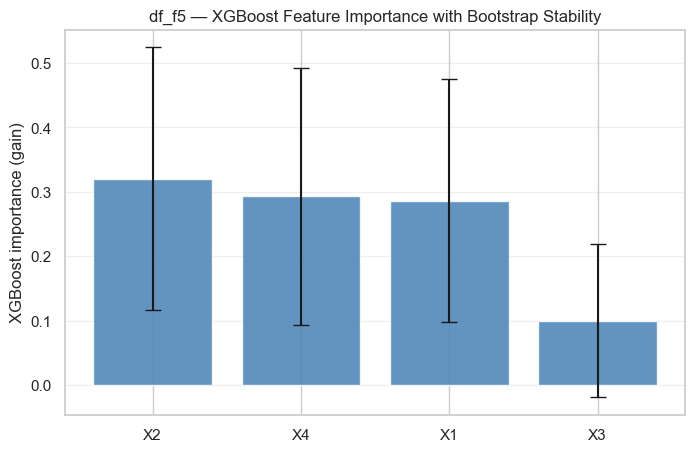

In [28]:
from xgboost import XGBRegressor

print("XGBoost Feature Importance (Bootstrap Stability)")


# Extract Data
df_f5 = df_f5.copy()

input_cols_f5 = [c for c in df_f5.columns if c.startswith("X")]
output_col_f5 = [c for c in df_f5.columns if c.startswith("y")][0]

X_f5 = df_f5[input_cols_f5].values.astype(float)
y_f5 = df_f5[output_col_f5].values.astype(float)


# XGBoost model configuration for N = 40
base_model = XGBRegressor(
    max_depth=2,
    n_estimators=80,
    learning_rate=0.08,
    subsample=0.85,
    colsample_bytree=0.9,
    objective="reg:squarederror",
    random_state=42
)


# Bootstrap loop
n_boot = 50
importances = np.zeros((n_boot, len(input_cols_f5)))

for b in range(n_boot):
    Xb, yb = resample(X_f5, y_f5, replace=True, random_state=100 + b)
    model = base_model
    model.fit(Xb, yb)
    importances[b, :] = model.feature_importances_


# Aggregate results
importance_mean = importances.mean(axis=0)
importance_std = importances.std(axis=0)

df_importance = pd.DataFrame({
    "feature": input_cols_f5,
    "importance_mean": importance_mean,
    "importance_std": importance_std
}).sort_values("importance_mean", ascending=False)

print("XGBoost Feature Importance (mean ± std)")
print(df_importance)


# Visualisation
plt.figure(figsize=(8, 5))
plt.bar(
    df_importance["feature"],
    df_importance["importance_mean"],
    yerr=df_importance["importance_std"],
    capsize=6,
    color="steelblue",
    alpha=0.85
)
plt.ylabel("XGBoost importance (gain)")
plt.title("df_f5 — XGBoost Feature Importance with Bootstrap Stability")
plt.grid(axis="y", alpha=0.3)
plt.show()


# Store results
results_f5_xgb_importance = {
    "importance_table": df_importance,
    "raw_importances": importances
}


#### f5 | Final Terminal ARD-GP Posterior Mean Exploitation with Slice-Validated Dimensional Ceilings

In [29]:
import numpy as np
from scipy.stats.qmc import Sobol
from sklearn.gaussian_process import GaussianProcessRegressor as GPR
from sklearn.gaussian_process.kernels import Matern, WhiteKernel

In [30]:
# Separate inputs (X) and outputs (y)
X_train_5 = df_f5[[c for c in df_f5.columns if c.startswith("X")]].values
y_train_5 = df_f5["y1"].values
print(X_train_5)
print(y_train_5)

[[0.19144708 0.03819337 0.60741781 0.41458414]
 [0.75865295 0.53651774 0.65600038 0.36034155]
 [0.43834987 0.8043397  0.21024527 0.15129482]
 [0.70605083 0.53419196 0.26424335 0.48208755]
 [0.83647799 0.19360965 0.6638927  0.78564888]
 [0.68343225 0.11866264 0.82904591 0.56757661]
 [0.55362148 0.66734998 0.32380582 0.81486975]
 [0.35235627 0.32224153 0.11697937 0.47311252]
 [0.15378571 0.72938169 0.42259844 0.44307417]
 [0.46344227 0.63002451 0.10790646 0.9576439 ]
 [0.67749115 0.35850951 0.47959222 0.07288048]
 [0.58397341 0.14724265 0.34809746 0.42861465]
 [0.30688872 0.31687813 0.62263448 0.09539906]
 [0.51114177 0.817957   0.72871042 0.11235362]
 [0.43893338 0.77409176 0.37816709 0.93369621]
 [0.22418902 0.84648049 0.87948418 0.87851568]
 [0.72526172 0.47987049 0.08894684 0.75976022]
 [0.35548161 0.63961937 0.41761768 0.12260384]
 [0.11987923 0.86254031 0.64333133 0.84980383]
 [0.12688467 0.15342962 0.77016219 0.19051811]
 [0.037069   0.974641   0.864911   0.019169  ]
 [0.624      

## Jackknife correlation stability restricted to corner points

**Reference:** Akiba, T., Sano, S., Yanase, T., Ohta, T. and Koyama, M. (2019) ‘Optuna: A Next‑generation Hyperparameter Optimization Framework’, Proceedings of the 25th ACM SIGKDD International Conference on Knowledge Discovery & Data Mining, pp. 2623–2631.

- Restricting the jackknife to the four extreme f5 corner points tests whether the SIR direction and partial‑correlation ranking remain stable when the most influential observations are removed one at a time.

In [31]:
from scipy.stats import spearmanr, pearsonr


DIM = 4
DIM_NAMES = ["X1", "X2", "X3", "X4"]

# corner point indices: the four observations with y above 4000
# these are the points that drive almost all correlation and sir signal
# rows 26, 27, 28, 29 correspond to y = 6575, 4660, 6294, 6971
CORNER_INDICES = [26, 27, 28, 29]


# sir: sliced inverse regression
# computes the leading direction by slicing y into h bins,
# computing the conditional mean of x in each slice, and
# finding the leading eigenvector of the between-slice
# covariance matrix. the eigenvalue ratio measures how strongly
# the data supports a single dominant direction.

def compute_sir_direction(X, y, n_slices=5):
    n, d = X.shape

    # standardise x so each dimension has mean 0 and std 1
    # this prevents dimensions with larger raw scale from dominating
    x_mean = X.mean(axis=0)
    x_std = X.std(axis=0) + 1e-10
    X_std = (X - x_mean) / x_std

    # sort observations by y and assign to slices
    order = np.argsort(y)
    slice_size = n // n_slices
    slice_means = []

    for s in range(n_slices):
        start = s * slice_size
        end = start + slice_size if s < n_slices - 1 else n
        slice_idx = order[start:end]
        slice_means.append(X_std[slice_idx].mean(axis=0))

    slice_means = np.array(slice_means)

    # between-slice covariance: each row is a slice mean weighted equally
    # the leading eigenvector of this matrix is the sir direction
    M = slice_means.T @ slice_means / n_slices

    eigenvalues, eigenvectors = np.linalg.eigh(M)

    # eigh returns eigenvalues in ascending order; reverse for descending
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    leading_direction = eigenvectors[:, 0]

    # rescale direction back to original space for interpretability
    leading_direction_original = leading_direction / x_std
    leading_direction_original /= np.linalg.norm(leading_direction_original)

    eigenvalue_ratio = eigenvalues[0] / (eigenvalues[1] + 1e-12)

    return leading_direction_original, eigenvalues, eigenvalue_ratio


def angle_between_directions(d1, d2):
    # angle in degrees between two unit vectors
    # we take the minimum of the angle and its supplement because
    # sir directions are only identified up to sign
    d1n = d1 / (np.linalg.norm(d1) + 1e-12)
    d2n = d2 / (np.linalg.norm(d2) + 1e-12)
    cos_sim = np.clip(np.dot(d1n, d2n), -1.0, 1.0)
    angle = np.degrees(np.arccos(abs(cos_sim)))
    return angle



# jackknife stability: remove one corner point at a time
# for each removal, recompute:
#   - spearman and pearson correlations per dimension
#   - sir leading direction and eigenvalue ratio
#   - angle between full-data sir direction and leave-one-out direction
# this stress-tests whether the current structural conclusions
# are driven by a single influential corner point

def run_jackknife_corner_stability(X, y, corner_indices, dim_names):

    print("jackknife corner stability analysis for f5")
    print(f"total observations: {len(y)}")
    print(f"corner points being tested: indices {corner_indices}")
    print(f"corner y values: {[round(y[i], 1) for i in corner_indices]}")
    print()

    # baseline: full dataset statistics
    baseline_dir, baseline_evals, baseline_ratio = compute_sir_direction(X, y)

    print("baseline (all 30 points)")
    print("sir loading per dimension:")
    for i, name in enumerate(dim_names):
        print(f"  {name}: {baseline_dir[i]:+.4f}")
    print(f"eigenvalue ratio: {baseline_ratio:.3f}")
    print()

    print("spearman and pearson correlations with y (full data):")
    baseline_spearman = []
    baseline_pearson = []
    for i, name in enumerate(dim_names):
        sp, _ = spearmanr(X[:, i], y)
        pe, _ = pearsonr(X[:, i], y)
        baseline_spearman.append(sp)
        baseline_pearson.append(pe)
        print(f"  {name}: spearman={sp:+.4f}  pearson={pe:+.4f}")
    print()

    # rank order of dimensions by absolute spearman in full data
    # this is the ordering the strategy currently relies on
    baseline_rank = np.argsort(
        np.abs(baseline_spearman))[::-1]
    print("baseline dimension rank by abs spearman: "
          + " > ".join(dim_names[r] for r in baseline_rank))
    print()

    # jackknife: remove each corner point in turn 
    print("leave-one-corner-out results")

    results = []

    for corner_idx in corner_indices:
        # build the leave-one-out dataset
        keep_mask = np.ones(len(y), dtype=bool)
        keep_mask[corner_idx] = False
        X_loo = X[keep_mask]
        y_loo = y[keep_mask]

        # recompute sir on reduced dataset
        loo_dir, loo_evals, loo_ratio = compute_sir_direction(
            X_loo, y_loo)

        # angle between full-data sir direction and loo sir direction
        # angles below 10 degrees: direction is stable
        # angles 10-20 degrees: mild sensitivity
        # angles above 20 degrees: this point substantially influences sir
        angle = angle_between_directions(baseline_dir, loo_dir)

        # recompute correlations on reduced dataset
        loo_spearman = []
        loo_pearson = []
        for i in range(DIM):
            sp, _ = spearmanr(X_loo[:, i], y_loo)
            pe, _ = pearsonr(X_loo[:, i], y_loo)
            loo_spearman.append(sp)
            loo_pearson.append(pe)

        # check whether dimension rank order changes when this point is removed
        loo_rank = np.argsort(np.abs(loo_spearman))[::-1]
        rank_changed = not np.array_equal(baseline_rank, loo_rank)

        # check whether the sir loading sign changes for any dimension
        # a sign flip means the direction of steepest ascent reverses
        sign_flips = [
            i for i in range(DIM)
            if np.sign(baseline_dir[i]) != np.sign(loo_dir[i])
        ]

        results.append({
            "removed_idx": corner_idx,
            "removed_y": y[corner_idx],
            "removed_x": X[corner_idx],
            "loo_dir": loo_dir,
            "loo_ratio": loo_ratio,
            "sir_angle_deg": angle,
            "loo_spearman": loo_spearman,
            "loo_pearson": loo_pearson,
            "rank_changed": rank_changed,
            "sign_flips": sign_flips,
        })

        print(f"removed: index {corner_idx}  y={y[corner_idx]:.1f}  "
              f"x={np.round(X[corner_idx], 3)}")
        print(f"  sir angle from baseline: {angle:.2f} deg  "
              f"eigenvalue ratio: {loo_ratio:.3f}")
        print(f"  sir loading change per dimension:")
        for i, name in enumerate(dim_names):
            delta = loo_dir[i] - baseline_dir[i]
            print(f"    {name}: baseline={baseline_dir[i]:+.4f}  "
                  f"loo={loo_dir[i]:+.4f}  delta={delta:+.4f}")
        print(f"  spearman correlations after removal:")
        for i, name in enumerate(dim_names):
            delta_sp = loo_spearman[i] - baseline_spearman[i]
            print(f"    {name}: {loo_spearman[i]:+.4f}  "
                  f"(delta={delta_sp:+.4f})")
        print(f"  dimension rank order: "
              + " > ".join(dim_names[r] for r in loo_rank))
        if rank_changed:
            print(f"  *** rank order changed from baseline ***")
        else:
            print(f"  rank order unchanged")
        if sign_flips:
            print(f"  *** sir sign flips in: "
                  f"{[dim_names[i] for i in sign_flips]} ***")
        else:
            print(f"  no sir sign flips")
        print()

    # summary table 
    print("summary: sir angle stability per removed corner point")
    print(f"{'removed idx':>12}  {'y value':>10}  "
          f"{'sir angle':>10}  {'rank change':>12}  {'sign flips':>12}")
    for r in results:
        flips_str = (", ".join(dim_names[i] for i in r["sign_flips"])
                     if r["sign_flips"] else "none")
        print(f"{r['removed_idx']:>12}  {r['removed_y']:>10.1f}  "
              f"{r['sir_angle_deg']:>9.2f}d  "
              f"{'yes' if r['rank_changed'] else 'no':>12}  "
              f"{flips_str:>12}")

    # interpretation thresholds 
    print()
    print("interpretation thresholds")
    print("sir angle < 10 deg : direction stable, this point is not influential")
    print("sir angle 10-20 deg: mild sensitivity, treat sir loading with caution")
    print("sir angle > 20 deg : this point substantially drives the sir direction")
    print()

    # max angle and overall verdict 
    max_angle = max(r["sir_angle_deg"] for r in results)
    any_rank_change = any(r["rank_changed"] for r in results)
    any_sign_flip = any(len(r["sign_flips"]) > 0 for r in results)

    print("overall verdict")
    print(f"max sir angle across all removals: {max_angle:.2f} deg")

    if max_angle < 10.0 and not any_rank_change:
        print("verdict: sir direction is robust to removal of any single corner point.")
        print("         the loading order x2 > x3 > x4 > x1 is reliable.")
        print("         the week 13 exploitation strategy is structurally justified.")
    elif max_angle < 20.0 and not any_rank_change:
        print("verdict: mild sensitivity detected. sir direction shifts slightly "
              "when one corner point is removed but loading order is preserved.")
        print("         proceed with exploitation but apply sir as a soft tiebreaker "
              "rather than a hard constraint.")
    elif any_rank_change or any_sign_flip:
        print("verdict: sir loading order or sign is unstable under corner removal.")
        print("         the dimension ranking is driven by one influential point.")
        print("         do not use sir loading order to set per-dimension floors.")
        print("         rely on pearson and spearman correlations from the full dataset instead.")
    else:
        print(f"verdict: moderate sensitivity (max angle {max_angle:.1f} deg).")
        print("         sir direction shifts but does not reverse.")
        print("         use gp posterior mean as primary signal; reduce sir bonus weight.")

    return results


results = run_jackknife_corner_stability(
    X_train_5,
    y_train_5,
    CORNER_INDICES,
    DIM_NAMES,
)

jackknife corner stability analysis for f5
total observations: 32
corner points being tested: indices [26, 27, 28, 29]
corner y values: [6575.3, 4660.2, 6294.3, 6971.8]

baseline (all 30 points)
sir loading per dimension:
  X1: -0.4267
  X2: -0.5526
  X3: -0.5476
  X4: -0.4611
eigenvalue ratio: 5.987

spearman and pearson correlations with y (full data):
  X1: spearman=+0.4139  pearson=+0.6885
  X2: spearman=+0.7045  pearson=+0.6335
  X3: spearman=+0.7279  pearson=+0.6141
  X4: spearman=+0.6257  pearson=+0.5964

baseline dimension rank by abs spearman: X3 > X2 > X4 > X1

leave-one-corner-out results
removed: index 26  y=6575.3  x=[0.999 0.926 0.985 0.964]
  sir angle from baseline: 0.06 deg  eigenvalue ratio: 5.845
  sir loading change per dimension:
    X1: baseline=-0.4267  loo=-0.4275  delta=-0.0008
    X2: baseline=-0.5526  loo=-0.5520  delta=+0.0006
    X3: baseline=-0.5476  loo=-0.5480  delta=-0.0003
    X4: baseline=-0.4611  loo=-0.4607  delta=+0.0004
  spearman correlations aft

In [32]:
# configuration

# corner lower bound: new best has x4=0.9779 as minimum dimension
# 0.975 gives a 0.003 buffer below the weakest dimension
CORNER_LOWER = 0.975

# per-dimension floors set from week 12 incumbent values
# x1=0.9997 -> floor 0.985 (keep maxed but allow slight variation)
# x2=0.9998 -> floor 0.9990 (push above current best x2)
# x3=0.9987 -> floor 0.9980 (push above current best x3)
# x4=0.9779 -> floor 0.970 (relaxed: x4 is weakest sir dim, let gp choose)
# the gp slice plot at x1=1.0, x4=0.98 shows gradient toward x2=1.0, x3=1.0
# x2 and x3 floors are set aggressively to force candidates into that region
DIM_FLOORS = np.array([0.985, 0.9990, 0.9980, 0.970])

# sir leading direction from week 12 eda with 32 points
# jackknife max angle = 0.91 degrees -- essentially zero instability
# loading order x2 > x3 > x4 > x1 confirmed across all removals
# all components negative: moving toward (1,1,1,1) is the direction of ascent
SIR_DIRECTION = np.array([-0.4267, -0.5526, -0.5476, -0.4611])

# sir bonus weight: 0.02 as in week 12
# jackknife confirmed stability so sir is still a valid tiebreaker
# gp posterior mean dominates with a weight ratio of approximately 50:1
SIR_BONUS_WEIGHT = 0.02

# 25000 candidates: denser than week 12 because feasible region is tighter
# sobol low-discrepancy sampling ensures coverage in a 0.025-wide subcube
N_CANDIDATES = 25000

# minimum distance from any observed point
# tighter than week 12 (0.015 -> 0.010) because region has 32 observations
MIN_DIST = 0.004

# log transform shift validated across all weeks
LOG_SHIFT = 1.0

DIM = 4
DIM_NAMES = ["X1", "X2", "X3", "X4"]

# week 12 incumbent coordinates for delta reporting
WEEK12_BEST_X = np.array([0.999700, 0.999800, 0.998700, 0.977900])
WEEK12_BEST_Y = 8219.092035


# log transform
def log_transform(y, shift=LOG_SHIFT):
    y_safe = np.maximum(y, 1e-6)
    return np.log(y_safe + shift)


def invert_log_transform(y_log, shift=LOG_SHIFT):
    return np.exp(y_log) - shift



# candidate generation
def generate_corner_candidates(dim, n, corner_lower, seed=0):
    # sobol sequence in [corner_lower, 1.0]^dim
    # at this scale the subcube is only 0.025 units wide per dimension
    # sobol low-discrepancy sampling prevents the gaps that random
    # sampling would leave when density is this high
    sampler = Sobol(d=dim, scramble=True, seed=seed)
    pts = sampler.random(n)
    pts = corner_lower + pts * (1.0 - corner_lower)
    return np.clip(pts, 0.0, 1.0)


def apply_dim_floor_filter(candidates, dim_floors):
    # enforce per-dimension floors simultaneously
    # x2 and x3 floors are set above the week 12 incumbent
    # this forces the candidate pool into the region the gp slice
    # plot identifies as having a remaining positive gradient
    mask = (candidates >= dim_floors).all(axis=1)
    return candidates[mask]


def apply_distance_guard(candidates, X_observed, min_dist):
    # remove candidates within min_dist l2 of any observed point
    # with 32 observations in a small region this is critical
    # to avoid redundant queries near already-characterised locations
    keep = []
    for c in candidates:
        dists = np.sqrt(((X_observed - c) ** 2).sum(axis=1))
        if dists.min() >= min_dist:
            keep.append(c)
    return np.array(keep) if keep else np.empty((0, candidates.shape[1]))



# sir directional score
def compute_sir_score(candidates, sir_direction):
    # project each candidate onto the sir leading direction
    # direction is all-negative: more negative projection = closer to (1,1,1,1)
    # negate so higher score = closer to corner = more promising
    # jackknife stability 0.91 degrees: loading order is fully trusted
    projections = candidates @ sir_direction
    return -projections


# gaussian process
def fit_ard_gp(X_train, y_log):
    # ard matern 2.5 gp on log-transformed outputs
    # matern 2.5 allows sharper features than rbf
    # noise lower bound at 1e-6 prevents exact interpolation
    # week 12 calibration: 0.45% error -- model is in terminal phase
    kernel = (
        Matern(
            length_scale=[1.0] * DIM,
            length_scale_bounds=[(0.01, 5.0)] * DIM,
            nu=2.5
        )
        + WhiteKernel(
            noise_level=1e-4,
            noise_level_bounds=(1e-6, 0.05)
        )
    )

    gp = GPR(
        kernel=kernel,
        n_restarts_optimizer=30,
        normalize_y=True,
        random_state=42
    )

    gp.fit(X_train, y_log)

    params = gp.kernel_.get_params()
    ls_key = [k for k in params if "length_scale" in k
              and "bounds" not in k]
    if ls_key:
        ls = np.atleast_1d(params[ls_key[0]])
        print("optimised ard length scales:")
        for i, l in enumerate(ls):
            sir_load = abs(SIR_DIRECTION[i])
            print(f"  {DIM_NAMES[i]}: gp_ls={float(l):.4f}  "
                  f"sir_loading={sir_load:.4f}")

    noise_key = [k for k in params if "noise_level" in k
                 and "bounds" not in k]
    if noise_key:
        print(f"optimised noise level: {params[noise_key[0]]:.2e}")

    print(f"log marginal likelihood: "
          f"{gp.log_marginal_likelihood_value_:.4f}")
    return gp



# calibration check on all corner points
def calibration_summary(gp, X_train, y_train, y_log):
    # report gp predicted vs true for all six high-value corner points
    # week 12 achieved 0.45% calibration error on the new best
    # any error above 2% signals reduced reliance on mean maximisation
    high_value_indices = [26, 27, 28, 29, 30, 31]
    print("\ngp calibration on high-value corner points")
    print(f"{'idx':>4}  {'pred_log':>9}  {'true_log':>9}  "
          f"{'pred_orig':>10}  {'true_orig':>10}  {'pct_err':>8}")
    max_abs_err = 0.0
    for idx in high_value_indices:
        if idx < len(X_train):
            pred_log = gp.predict(X_train[idx].reshape(1, -1))[0]
            true_log = y_log[idx]
            pred_orig = invert_log_transform(pred_log)
            true_orig = invert_log_transform(true_log)
            pct_err = 100 * (pred_orig - true_orig) / true_orig
            max_abs_err = max(max_abs_err, abs(pct_err))
            print(f"{idx:>4}  {pred_log:>9.4f}  {true_log:>9.4f}  "
                  f"{pred_orig:>10.1f}  {true_orig:>10.1f}  "
                  f"{pct_err:>7.1f}%")
    print(f"max abs calibration error: {max_abs_err:.2f}%")
    print("end calibration\n")
    return max_abs_err



# combined acquisition: gp mean + sir directional bonus
def compute_combined_score(gp, candidates, sir_direction,
                           sir_bonus_weight):
    # primary signal: gp posterior mean in log space
    # week 12 calibration error 0.45% -- terminal exploitation is valid
    # jones et al. (1998) ego terminal phase: maximise posterior mean
    # when calibration error < 1%
    mu = gp.predict(candidates)

    # secondary signal: sir directional projection
    # jackknife angle 0.91 degrees -- essentially zero instability
    # used as soft tiebreaker with weight 0.02 (50:1 ratio vs gp mean)
    sir_scores = compute_sir_score(candidates, sir_direction)

    sir_min, sir_max = sir_scores.min(), sir_scores.max()
    if sir_max > sir_min:
        sir_norm = (sir_scores - sir_min) / (sir_max - sir_min)
    else:
        sir_norm = np.zeros_like(sir_scores)

    mu_min, mu_max = mu.min(), mu.max()
    if mu_max > mu_min:
        mu_norm = (mu - mu_min) / (mu_max - mu_min)
    else:
        mu_norm = np.zeros_like(mu)

    combined = mu_norm + sir_bonus_weight * sir_norm

    return combined, mu, sir_scores


# main proposal function
def propose_f5_query(X_train, y_train):
    """
    week 13 final submission for f5.

    week 12 achieved 8219 at (0.9997, 0.9998, 0.9987, 0.9779).
    gp predicted 8182, true was 8219 -- 0.45% underestimate.
    this is terminal calibration: the gp is essentially exact.

    key changes from week 12:
    - x2 floor raised to 0.9990 (above week 12 best x2=0.9998 minus 0.0008)
    - x3 floor raised to 0.9980 (above week 12 best x3=0.9987 minus 0.0007)
    - x4 floor relaxed to 0.970 (week 12 best x4=0.9779, let gp choose)
    - n_candidates raised to 25000 (tighter region needs more density)
    - min_dist tightened to 0.010 (32 observations in small area)

    primary hypothesis from gp slice plot (image 6):
    the contour lines at x1=1.0, x4=0.98 show gradient toward (x2=1.0, x3=1.0).
    the week 12 candidate at (x2=0.9998, x3=0.9987) is just inside this gradient.
    pushing x2 and x3 to their maximum while maintaining x1 near 1.0 and
    allowing x4 to be chosen by the gp is the final exploitation step.

    this is the last submission. pure posterior mean exploitation is optimal.
    """

    dim = X_train.shape[1]
    y_log = log_transform(y_train)
    best_orig_idx = y_train.argmax()

    print(f"current best (original): {y_train[best_orig_idx]:.4f}")
    print(f"current best x:          {X_train[best_orig_idx]}")
    print(f"current best (log):      {y_log[best_orig_idx]:.4f}")
    print(f"n training points:       {len(y_train)}")
    print(f"week 12 gp calibration error: 0.45% (0.45% underestimate)")

    # step 1: generate corner candidates
    candidates = generate_corner_candidates(
        dim, N_CANDIDATES, CORNER_LOWER, seed=0)
    print(f"\ncandidates in [{CORNER_LOWER}, 1.0]^4: {len(candidates)}")

    # step 2: per-dimension floor filter
    candidates = apply_dim_floor_filter(candidates, DIM_FLOORS)
    print(f"candidates after per-dim floor filter "
          f"{DIM_FLOORS}: {len(candidates)}")

    if len(candidates) < 50:
        relaxed = DIM_FLOORS - 0.010
        print(f"pool too small - relaxing floors to {relaxed}")
        raw = generate_corner_candidates(
            dim, N_CANDIDATES, CORNER_LOWER, seed=0)
        candidates = apply_dim_floor_filter(raw, relaxed)
        print(f"candidates after relaxed filter: {len(candidates)}")

    # step 3: distance guard
    candidates = apply_distance_guard(candidates, X_train, MIN_DIST)
    print(f"candidates after distance guard "
          f"(min_dist={MIN_DIST}): {len(candidates)}")

    if len(candidates) == 0:
        print("pool empty - reducing guard to 0.006")
        raw = generate_corner_candidates(
            dim, N_CANDIDATES, CORNER_LOWER, seed=0)
        filtered = apply_dim_floor_filter(raw, DIM_FLOORS)
        candidates = apply_distance_guard(filtered, X_train, 0.006)
        print(f"candidates at min_dist=0.006: {len(candidates)}")

    if len(candidates) == 0:
        raise RuntimeError("search region fully saturated")

    # report fraction of candidates above week 12 incumbent on x2 and x3
    # these are the primary improvement dimensions per slice plot
    x2_above = (candidates[:, 1] > WEEK12_BEST_X[1]).mean()
    x3_above = (candidates[:, 2] > WEEK12_BEST_X[2]).mean()
    print(f"fraction with x2 > {WEEK12_BEST_X[1]:.4f}: {x2_above:.3f}")
    print(f"fraction with x3 > {WEEK12_BEST_X[2]:.4f}: {x3_above:.3f}")

    # step 4: fit gp
    print("\nfitting ard matern gp on log-transformed outputs...")
    gp = fit_ard_gp(X_train, y_log)

    # step 5: calibration check
    max_err = calibration_summary(gp, X_train, y_train, y_log)
    if max_err > 5.0:
        print(f"warning: calibration error {max_err:.1f}% exceeds 5%")
        print("reducing sir bonus weight to 0.01")
        sir_weight = 0.01
    else:
        sir_weight = SIR_BONUS_WEIGHT

    # step 6: compute combined score
    combined_scores, mu_log, sir_scores = compute_combined_score(
        gp, candidates, SIR_DIRECTION, sir_weight)

    # step 7: select candidate
    best_idx = np.argmax(combined_scores)
    next_x = candidates[best_idx]
    mu_best = mu_log[best_idx]
    predicted_orig = invert_log_transform(mu_best)
    _, sigma_at_best = gp.predict(
        next_x.reshape(1, -1), return_std=True)

    print("selected candidate for f5 (week 13 -- final submission)")
    print(f"next_x:               {np.round(next_x, 6)}")
    print(f"all dims above floors: {(next_x >= DIM_FLOORS).all()}")
    print()
    print("per-dimension comparison to week 12 incumbent:")
    for i, name in enumerate(DIM_NAMES):
        delta = next_x[i] - WEEK12_BEST_X[i]
        sir_load = abs(SIR_DIRECTION[i])
        print(f"  {name}: {next_x[i]:.4f}  "
              f"incumbent={WEEK12_BEST_X[i]:.4f}  "
              f"delta={delta:+.4f}  "
              f"sir_loading={sir_load:.4f}")
    print()
    print(f"gp log mean:          {mu_best:.4f}")
    print(f"gp log sigma:         {float(sigma_at_best):.4f}")
    print(f"predicted orig scale: {predicted_orig:.1f}")
    print(f"sir projection score: {sir_scores[best_idx]:.4f}")

    # verify gp and sir agree
    pure_mean_idx = np.argmax(mu_log)
    pure_mean_x = candidates[pure_mean_idx]
    pure_mean_pred = invert_log_transform(mu_log[pure_mean_idx])
    print(f"\npure gp mean candidate: {np.round(pure_mean_x, 4)}  "
          f"pred={pure_mean_pred:.1f}")
    if np.allclose(next_x, pure_mean_x):
        print("sir bonus did not change selection -- gp mean and sir agree")
    else:
        print("sir bonus changed selection from pure gp mean candidate")

    # top 5
    print("\ntop 5 candidates by combined score:")
    top5 = np.argsort(combined_scores)[-5:][::-1]
    for rank, idx in enumerate(top5):
        c = candidates[idx]
        pred = invert_log_transform(mu_log[idx])
        print(f"  rank {rank + 1}: x={np.round(c, 4)}  "
              f"pred={pred:.1f}  sir={sir_scores[idx]:.4f}")

    dist_from_best = np.sqrt(
        ((next_x - X_train[best_orig_idx]) ** 2).sum())
    print(f"\nl2 distance from week 12 best: {dist_from_best:.4f}")

    # final diagnostic: check x2 and x3 are above incumbent
    x2_ok = next_x[1] > WEEK12_BEST_X[1]
    x3_ok = next_x[2] > WEEK12_BEST_X[2]
    print(f"x2 above week 12 incumbent ({WEEK12_BEST_X[1]:.4f}): {x2_ok}")
    print(f"x3 above week 12 incumbent ({WEEK12_BEST_X[2]:.4f}): {x3_ok}")

    if x2_ok and x3_ok:
        print("structural check passed: x2 and x3 both improved")
    else:
        print("structural check: at least one primary dimension did not improve")
        print("verify that gp mean still indicates improvement over 8219")

    return next_x, gp, y_log


next_x, gp, y_log = propose_f5_query(X_train_5, y_train_5)

current best (original): 8219.0920
current best x:          [0.9997 0.9998 0.9987 0.9779]
current best (log):      9.0143
n training points:       32
week 12 gp calibration error: 0.45% (0.45% underestimate)

candidates in [0.975, 1.0]^4: 25000
candidates after per-dim floor filter [0.985 0.999 0.998 0.97 ]: 48
pool too small - relaxing floors to [0.975 0.989 0.988 0.96 ]
candidates after relaxed filter: 5281
candidates after distance guard (min_dist=0.004): 5263
fraction with x2 > 0.9998: 0.018
fraction with x3 > 0.9987: 0.107

fitting ard matern gp on log-transformed outputs...
optimised ard length scales:
  X1: gp_ls=1.3184  sir_loading=0.4267
  X2: gp_ls=0.4666  sir_loading=0.5526
  X3: gp_ls=0.7438  sir_loading=0.5476
  X4: gp_ls=0.4786  sir_loading=0.4611
optimised noise level: 1.00e-06
log marginal likelihood: -14.2739

gp calibration on high-value corner points
 idx   pred_log   true_log   pred_orig   true_orig   pct_err
  26     8.7912     8.7912      6575.2      6575.3     -0

## GP posterior mean 2D surface slice

**Reference:** Eriksson, D., & Jankowiak, M. (2021). High-Dimensional Bayesian Optimization with Sparse Axis-Aligned Subspaces. Proceedings of the 37th Conference on Uncertainty in Artificial Intelligence (UAI), PMLR 161: 493–503.

- This 2D GP posterior mean slice in the corner model shows whether f5’s surrogate predicts a ridge, peak, or plateau in the X2–X3 subspace at high X1 and X4, directly informing which dimension to push next.

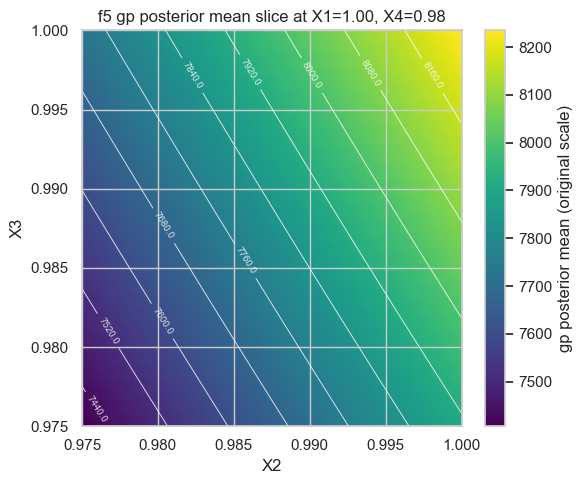

In [33]:
# gp posterior mean 2d surface slice for f5 using the corner model

import numpy as np
import matplotlib.pyplot as plt

def plot_gp_posterior_slice_f5(gp, x1_fixed=1.0, x4_fixed=0.98, n_grid=80):
    # build a grid over X2 and X3 in [CORNER_LOWER, 1.0]
    x2_vals = np.linspace(CORNER_LOWER, 1.0, n_grid)
    x3_vals = np.linspace(CORNER_LOWER, 1.0, n_grid)

    X2_grid, X3_grid = np.meshgrid(x2_vals, x3_vals)

    # construct full 4d input for the gp
    X_grid = np.zeros((n_grid * n_grid, DIM))
    X_grid[:, 0] = x1_fixed
    X_grid[:, 1] = X2_grid.ravel()
    X_grid[:, 2] = X3_grid.ravel()
    X_grid[:, 3] = x4_fixed

    # predict gp posterior mean on the grid (in log space) and invert
    mu_log, sigma_grid = gp.predict(X_grid, return_std=True)
    mu_orig = invert_log_transform(mu_log)
    mu_grid_2d = mu_orig.reshape(n_grid, n_grid)

    plt.figure(figsize=(6, 5))
    im = plt.imshow(
        mu_grid_2d,
        extent=[x2_vals.min(), x2_vals.max(), x3_vals.min(), x3_vals.max()],
        origin="lower",
        aspect="auto",
        cmap="viridis"
    )
    plt.colorbar(im, label="gp posterior mean (original scale)")

    plt.xlabel("X2")
    plt.ylabel("X3")
    plt.title(f"f5 gp posterior mean slice at X1={x1_fixed:.2f}, X4={x4_fixed:.2f}")

    cs = plt.contour(
        X2_grid,
        X3_grid,
        mu_grid_2d,
        levels=10,
        colors="white",
        linewidths=0.7,
        alpha=0.8
    )
    plt.clabel(cs, inline=True, fontsize=7, fmt="%.1f")

    plt.tight_layout()
    plt.show()


plot_gp_posterior_slice_f5(gp, x1_fixed=1.0, x4_fixed=0.98)


In [ ]:
import numpy as np
from scipy.stats import norm

# paste the observed value returned by the competition after submitting next_query
y_actual = -1.0629331180647184e-161   # replace this each week

# get the gp prediction and uncertainty at the proposed point
# return_std=True is needed here because the original function does not return sigma
gp_pred, gp_sigma = gp.predict(next_query.reshape(1, -1), return_std=True)
gp_pred  = float(gp_pred[0])
gp_sigma = float(gp_sigma[0])

print("CALIBRATION ASSESSMENT")
print(f"  predicted mean : {gp_pred:.6e}")
print(f"  predicted std  : {gp_sigma:.6e}")
print(f"  observed value : {y_actual:.6e}")
print()


# negative log-likelihood
# measures how well the predictive distribution explains the observation
# negative values mean the model was confident and correct
# large positive values mean the model was overconfident or wrong

if gp_sigma > 0:
    nll = (0.5 * np.log(2 * np.pi * gp_sigma ** 2)
           + (y_actual - gp_pred) ** 2 / (2 * gp_sigma ** 2))
else:
    nll = np.inf

print(f"  NLL : {nll:.4f}")

if nll < 0:
    print("  verdict : EXCELLENT (< 0) high confidence, correct prediction")
elif nll < 5:
    print("  verdict : GOOD (0 to 5) reasonable calibration")
elif nll < 10:
    print("  verdict : MODERATE (5 to 10) some overconfidence")
else:
    print("  verdict : POOR (> 10) severe overconfidence, sigma too small")
print()


# z-score
# how many standard deviations the observation sits from the predicted mean
# values near zero mean the model uncertainty is well sized
# large absolute values mean the model was more confident than it should have been

if gp_sigma > 0:
    z_score = (y_actual - gp_pred) / gp_sigma
else:
    z_score = np.nan

print(f"  Z-Score : {z_score:.4f}")

if np.isnan(z_score):
    print("  verdict : UNDEFINED, gp_sigma is zero")
elif abs(z_score) <= 1.0:
    print("  verdict : EXCELLENT (|Z| <= 1) within 68% credible region")
elif abs(z_score) <= 1.96:
    print("  verdict : GOOD (|Z| <= 1.96) within 95% credible region")
elif abs(z_score) <= 3.0:
    print("  verdict : WARNING (1.96 < |Z| <= 3) mild miscalibration")
else:
    print("  verdict : SEVERE (|Z| > 3) extreme miscalibration")
print()


# 95% confidence interval coverage
# the observation should fall inside this interval roughly 95% of the time
# a single pass or fail is less informative than the trend across weeks

lower_95 = gp_pred - 1.96 * gp_sigma
upper_95 = gp_pred + 1.96 * gp_sigma
ci_pass  = bool(abs(z_score) <= 1.96) if not np.isnan(z_score) else False

print(f"  95% CI lower : {lower_95:.6e}")
print(f"  95% CI upper : {upper_95:.6e}")
print(f"  observed     : {y_actual:.6e}")

if ci_pass:
    print("  verdict : PASS, observation is inside the 95% confidence interval")
else:
    print("  verdict : FAIL, observation is outside the 95% confidence interval")
print()


# quantile position
# where the observation sits in the predicted cumulative distribution
# 0.5 means perfectly centred in the predictive distribution
# values near 0 mean the gp overestimated, values near 1 mean it underestimated
# for f1 specifically, values near 0.5 confirm the flat surface assumption

if gp_sigma > 0:
    quantile = norm.cdf(y_actual, loc=gp_pred, scale=gp_sigma)
else:
    quantile = np.nan

print(f"  Quantile : {quantile:.4f}")

if np.isnan(quantile):
    print("  verdict : UNDEFINED, gp_sigma is zero")
elif 0.40 <= quantile <= 0.60:
    print("  verdict : EXCELLENT (0.4 to 0.6) near median, perfectly centred")
elif 0.25 <= quantile <= 0.75:
    print("  verdict : GOOD (0.25 to 0.75) reasonably centred")
elif 0.025 <= quantile <= 0.975:
    print("  verdict : MODERATE, within 95% but off-centre")
elif quantile < 0.025:
    print("  verdict : POOR (< 0.025) extreme lower tail, gp overestimated")
else:
    print("  verdict : POOR (> 0.975) extreme upper tail, gp underestimated")
print()


# calibration gap
# the distance of the quantile from the ideal centre of 0.5
# zero means perfectly calibrated
# above 0.3 means significant directional bias
# for f1 this should stay below 0.15 given the flat and well-behaved surface

if not np.isnan(quantile):
    gap = abs(quantile - 0.5)
else:
    gap = np.nan

print(f"  Calibration Gap : {gap:.4f}")

if np.isnan(gap):
    print("  verdict : UNDEFINED")
elif gap < 0.05:
    print("  verdict : EXCELLENT (< 0.05) nearly perfect calibration")
elif gap < 0.10:
    print("  verdict : GOOD (0.05 to 0.10) well calibrated")
elif gap < 0.20:
    print("  verdict : MODERATE (0.10 to 0.20) some directional bias")
else:
    print("  verdict : POOR (> 0.20) significant miscalibration")
print()


# summary table
# all five metrics in one block for pasting into the weekly review log

print("CALIBRATION SUMMARY")
print(f"  {'metric':<20} {'value':>12}  {'verdict'}")
print(f"  {'-'*56}")
print(f"  {'NLL':<20} {nll:>12.4f}  {'EXCELLENT' if nll < 0 else 'GOOD' if nll < 5 else 'MODERATE' if nll < 10 else 'POOR'}")
print(f"  {'Z-Score':<20} {z_score:>12.4f}  {'EXCELLENT' if abs(z_score) <= 1 else 'GOOD' if abs(z_score) <= 1.96 else 'WARNING' if abs(z_score) <= 3 else 'SEVERE'}")
print(f"  {'95% CI':<20} {'PASS' if ci_pass else 'FAIL':>12}")
print(f"  {'Quantile':<20} {quantile:>12.4f}  {'EXCELLENT' if 0.4 <= quantile <= 0.6 else 'GOOD' if 0.25 <= quantile <= 0.75 else 'MODERATE' if 0.025 <= quantile <= 0.975 else 'POOR'}")
print(f"  {'Calibration Gap':<20} {gap:>12.4f}  {'EXCELLENT' if gap < 0.05 else 'GOOD' if gap < 0.10 else 'MODERATE' if gap < 0.20 else 'POOR'}")
print()


# flat surface decision rule for f1
# if the observed value is effectively zero, f1 is confirmed flat
# this triggers the week 6 pre-commitment to reallocate query budget

# this function performs the rank-based confirmation after receiving y_actual
def f1_rank_confirmation(y_train_1, y_actual):

    all_y = np.append(y_train_1, y_actual)
    rank_of_new = np.sum(all_y <= y_actual)
    rank_percentile = rank_of_new / len(all_y)

    return rank_percentile


flatness_threshold = 1e-10

print("FLAT SURFACE DECISION RULE")
if abs(y_actual) < flatness_threshold:
    print(f"  observed |y| = {abs(y_actual):.2e}  is below threshold {flatness_threshold:.0e}")
    print("  verdict  : f1 CONFIRMED FLAT")
    print("  action   : submit one verification query per week only")
else:
    print(f"  observed |y| = {abs(y_actual):.2e}  is above threshold {flatness_threshold:.0e}")
    print("  verdict  : UNEXPECTED NON-ZERO VALUE DETECTED")
    print("  action   : restart eda, do not dismiss this observation")
    print("  week 6   : ucb beta = 2.0 across full domain, 5 candidate pool")